In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from pathlib import Path
import cv2
import time
import random
from PIL import Image 

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim import lr_scheduler
import torchvision
from keras import utils
from torchvision import datasets, transforms
from tensorflow.keras.optimizers import SGD

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import optimizers

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import InceptionResNetV2

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [3]:
data_dir= r"D:\acedemic\5th sem\bone fracture\Bone Break Classification\Bone Break Classification"

In [4]:
train_data=utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40,
)

Found 1129 files belonging to 10 classes.
Using 1017 files for training.


In [5]:
vald_data=utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40,
)

Found 1129 files belonging to 10 classes.
Using 112 files for validation.


In [6]:
for images,lables in train_data.take(1):
  print(images.shape)
  print(lables.shape)

(64, 256, 256, 3)
(64,)


In [7]:
for images,lables in vald_data.take(1):
  print(images.shape)
  print(lables.shape)

(64, 256, 256, 3)
(64,)


In [8]:
classes=train_data.class_names
print(classes)

['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [9]:
def normalize(image, label):
  return image/255.0, label

train_data = train_data.map(normalize)

In [10]:
vald_data= vald_data.map(normalize)


In [11]:
train_x=[]
train_y=[]
for image,label in train_data:
   train_x.append(image)
   train_y.append(label)
   print(type(train_y))
train_x = tf.concat(train_x, axis=0)
train_y = tf.concat(train_y, axis=0)


<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


In [12]:
print(train_y)
type(train_y)

tf.Tensor([2 7 0 ... 8 4 2], shape=(1017,), dtype=int32)


tensorflow.python.framework.ops.EagerTensor

In [13]:
train_data = utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40
)


Found 1129 files belonging to 10 classes.
Using 1017 files for training.


In [14]:
class_names = train_data.class_names
print("Class names:", class_names)

Class names: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [15]:
val_x=[]
val_y=[]
for image,label in train_data:
   val_x.append(image)
   val_y.append(label)
val_x = tf.concat(val_x, axis=0)
val_y = tf.concat(val_y, axis=0)

In [16]:
num_classes = 10
train_y = tf.keras.utils.to_categorical(train_y, num_classes=num_classes)
val_y = tf.keras.utils.to_categorical(val_y, num_classes=num_classes)

In [17]:
model = Sequential()
model.add(Conv2D(60, (3, 3), activation='relu', input_shape=(256, 256, 3)))

model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(120, (3, 3), activation='relu'))

model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(40, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\Users\Abhishek iti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 60)        │           1,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 60)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 120)       │          64,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 120)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 461280)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 40)                  │      18,451,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             410 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,518,250 (70.64 MB)

 Trainable params: 18,518,250 (70.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
history = model.fit(train_x, train_y, batch_size=10, epochs=10)


Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 70s 666ms/step - accuracy: 0.1156 - loss: 3.0449 
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 68s 668ms/step - accuracy: 0.1992 - loss: 2.2535 
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 712ms/step - accuracy: 0.4209 - loss: 1.7690 
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 70s 683ms/step - accuracy: 0.6960 - loss: 1.1211 
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 71s 699ms/step - accuracy: 0.8749 - loss: 0.4790 
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 74s 725ms/step - accuracy: 0.9296 - loss: 0.2870 
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 68s 664ms/step - accuracy: 0.9777 - loss: 0.1981 
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 710ms/step - accuracy: 0.9728 - loss: 0.2557 
Epoch 9/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 69s 671ms/step - accuracy: 0.9950 - loss: 0.0491 
Epoch 10/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 67s 661ms/step - accuracy: 0.9820 - loss: 0.1959 


In [21]:
train_loss, train_accuracy = model.evaluate(train_x,train_y, verbose=0)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

test_loss, test_accuracy = model.evaluate(val_x,val_y, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 99.12%
Test Accuracy: 99.21%


In [22]:
CLASSES = np.array(class_names)

preds = model.predict(val_x)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 363ms/step


In [23]:
preds_single = CLASSES[np.argmax(preds, axis=-1)]
actual_single = CLASSES[np.argmax(val_y, axis=-1)]

In [24]:
def display_preds_act(n=10, figsize=(15, 3)):
    indices = np.random.choice(range(len(val_x)), n)  # Sample from images, not labels
    
    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(wspace=0.5, hspace=0.5)
    
    for i, idx in enumerate(indices):
        img = val_x[idx]  # Retrieve the image data
        ax = fig.add_subplot(1, n, i + 1)
        ax.axis("off")
        ax.text(0.5, -0.35, "pred = " + str(preds_single[idx].split(" ")[0][:4]), fontsize=10, ha="center", transform=ax.transAxes)
        ax.text(0.5, -0.7, "act = " + str(actual_single[idx].split(" ")[0][:4]), fontsize=10, ha="center", transform=ax.transAxes)
        ax.imshow(img)  # Display the image
    
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.6875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.8268585..245.29092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [11.302734..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..203.29395].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [11.5..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..244.56543].
Clipping input data to the valid

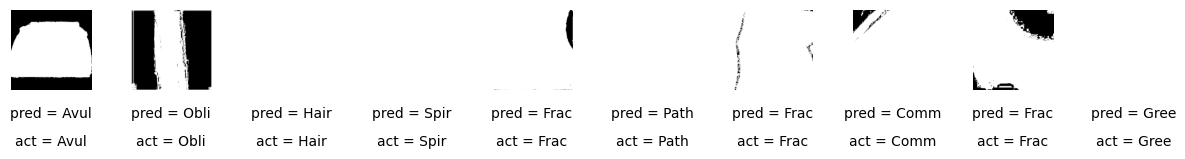

In [25]:
display_preds_act(n=10)

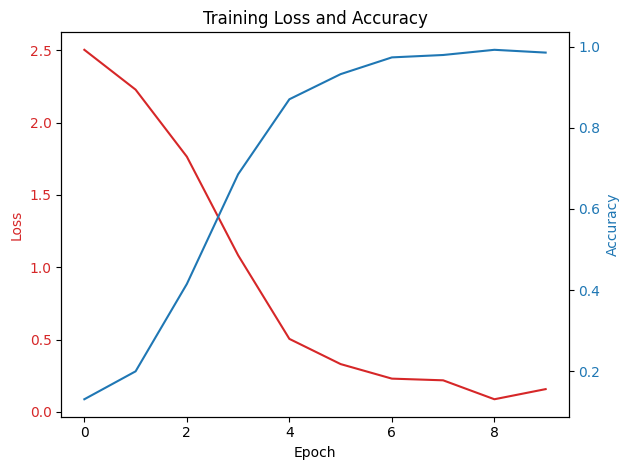

In [26]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history.history['loss'], color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(history.history['accuracy'], color='tab:blue', label='Train Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Training Loss and Accuracy')
fig.tight_layout()
plt.show()

In [27]:
y_pred = model.predict(val_x)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(val_y, axis=1)

class_names = [
    'Avulsion fracture', 
    'Comminuted fracture', 
    'Fracture Dislocation',
    'Greenstick fracture',
    'Hairline Fracture',
    'Impacted fracture',
    'Longitudinal fracture',
    'Oblique fracture',
    'Pathological fracture',
    'Spiral Fracture'
]

report = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
print(report)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 364ms/step
                       precision    recall  f1-score   support

    Avulsion fracture       1.00      1.00      1.00       109
  Comminuted fracture       1.00      0.99      1.00       127
 Fracture Dislocation       1.00      1.00      1.00       146
  Greenstick fracture       0.99      1.00      1.00       112
    Hairline Fracture       1.00      0.99      1.00       102
    Impacted fracture       1.00      0.96      0.98        76
Longitudinal fracture       0.96      0.99      0.97        76
     Oblique fracture       1.00      1.00      1.00        75
Pathological fracture       1.00      1.00      1.00       115
      Spiral Fracture       0.95      0.97      0.96        79

             accuracy                           0.99      1017
            macro avg       0.99      0.99      0.99      1017
         weighted avg       0.99      0.99      0.99      1017



In [28]:
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Calculate per-class metrics
precision1 = precision_score(y_true_classes, y_pred_classes, average=None)
recall1 = recall_score(y_true_classes, y_pred_classes, average=None)
f11 = f1_score(y_true_classes, y_pred_classes, average=None)
mcc1 = matthews_corrcoef(y_true_classes, y_pred_classes)
kappa = cohen_kappa_score(y_true_classes, y_pred_classes)

# For specificity, we need to compute it manually
specificity1 = []
for i in range(conf_matrix.shape[0]):
    # True Negatives: sum all elements except the ith row and ith column
    tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
    # False Positives: sum the ith column except the diagonal
    fp = np.sum(conf_matrix[:, i]) - conf_matrix[i, i]
    # False Negatives: sum the ith row except the diagonal
    fn = np.sum(conf_matrix[i, :]) - conf_matrix[i, i]
    # True Positives: diagonal element
    tp = conf_matrix[i, i]
    specificity1.append(tn / (tn + fp))
print(f"Precision per class: {precision1}")
print(f"Recall per class: {recall1}")
print(f"F1 Score per class: {f11}")
print(f"Specificity per class: {specificity1}")
print(f"Cohen's Kappa Score: {kappa}")
print(f"Matthews Correlation Coefficient (MCC): {mcc1}")

Precision per class: [1.         1.         1.         0.99115044 1.         1.
 0.96153846 1.         1.         0.95061728]
Recall per class: [1.         0.99212598 1.         1.         0.99019608 0.96052632
 0.98684211 1.         1.         0.97468354]
F1 Score per class: [1.         0.99604743 1.         0.99555556 0.99507389 0.97986577
 0.97402597 1.         1.         0.9625    ]
Specificity per class: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9988950276243094), np.float64(1.0), np.float64(1.0), np.float64(0.9968119022316685), np.float64(1.0), np.float64(1.0), np.float64(0.9957356076759062)]
Cohen's Kappa Score: 0.9912081927195278
Matthews Correlation Coefficient (MCC): 0.9912189042483687


In [29]:
print(conf_matrix)

[[109   0   0   0   0   0   0   0   0   0]
 [  0 126   0   0   0   0   1   0   0   0]
 [  0   0 146   0   0   0   0   0   0   0]
 [  0   0   0 112   0   0   0   0   0   0]
 [  0   0   0   0 101   0   0   0   0   1]
 [  0   0   0   1   0  73   0   0   0   2]
 [  0   0   0   0   0   0  75   0   0   1]
 [  0   0   0   0   0   0   0  75   0   0]
 [  0   0   0   0   0   0   0   0 115   0]
 [  0   0   0   0   0   0   2   0   0  77]]


In [30]:
class_names_dict = {
    0: 'Avulsion fracture', 
    1: 'Comminuted fracture', 
    2: 'Fracture Dislocation',
    3: 'Greenstick fracture',
    4: 'Hairline Fracture',
    5: 'Impacted fracture',
    6: 'Longitudinal fracture',
    7: 'Oblique fracture',
    8: 'Pathological fracture',
    9: 'Spiral Fracture'
}

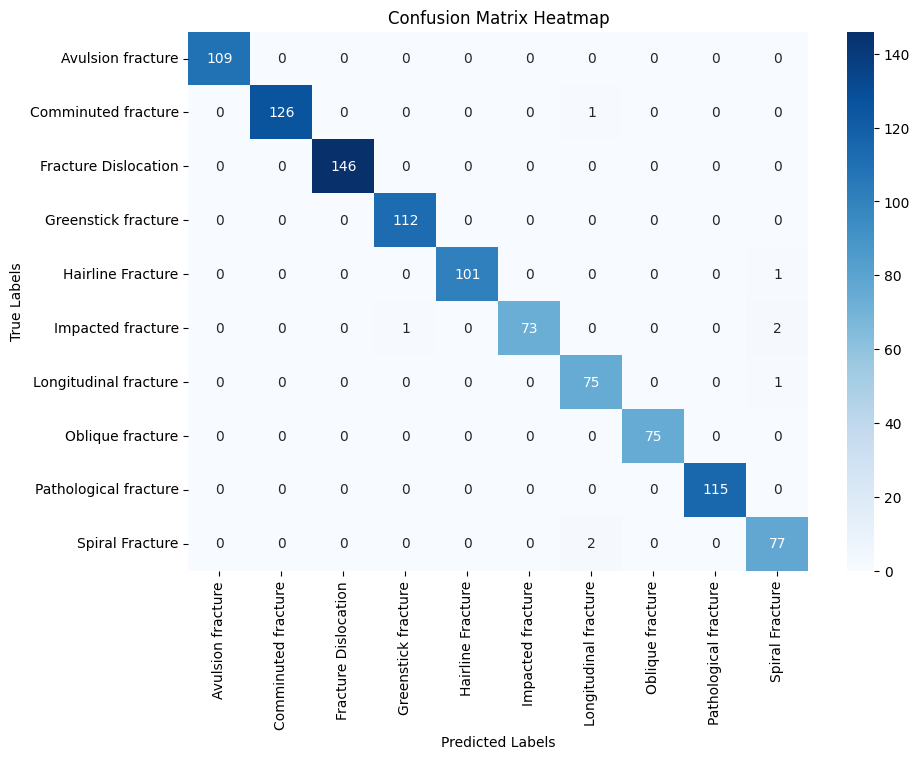

In [31]:
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(class_names_dict.values()),
            yticklabels=list(class_names_dict.values()))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [32]:
model.save("BONE NET V2.h5")

In [33]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the saved model
model = load_model("BONE NET V2.h5")

# Load and preprocess the image
image_path = image_path = r"D:\acedemic\5th sem\bone fracture\Bone Break Classification\Bone Break Classification\Fracture Dislocation\Test\9c1cbdeaa3a92cda049b03cfc58323_jumbo_jpeg.rf.96d8da3e8e693938cf66f704952d954b.jpg"
  # Replace with the path to your image
img = image.load_img(image_path, target_size=(256, 256))  # Resize to 256x256
img_array = image.img_to_array(img)  # Convert to numpy array
img_array = img_array / 255.0  # Normalize the image
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch size

# Predict the class
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions, axis=-1)[0]

# Map the predicted class index to the class name
class_names = [
    'Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation',
    'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture',
    'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture',
    'Spiral Fracture'
]
print(f"Predicted Class: {class_names[predicted_class]}")
 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predicted Class: Fracture Dislocation


Found 1129 files belonging to 10 classes.
Using 1017 files for training.
Found 1129 files belonging to 10 classes.
Using 112 files for validation.
Feature extractor loaded.
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step
Training features shape: (1017, 32768)
Validation features shape: (112, 32768)
KNN model trained.
Training Accuracy: 53.26%
Test Accuracy: 14.71%
Validation Accuracy: 16.07%
 

C:\Users\Abhishek iti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Abhishek iti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Abhishek iti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

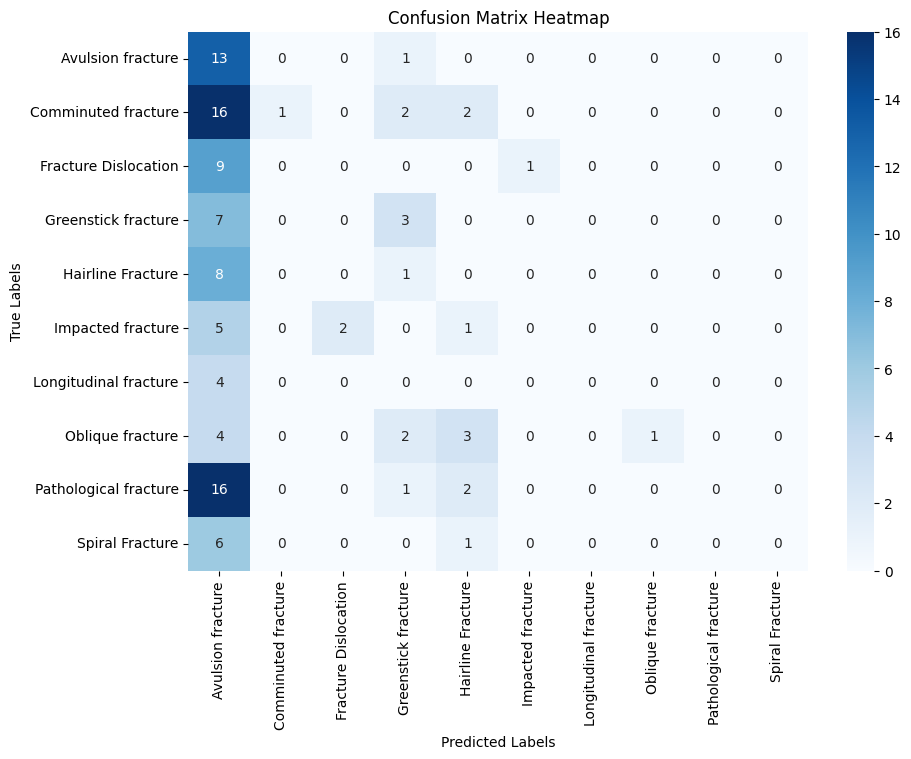

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing import image_dataset_from_directory
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data_dir = r"D:\acedemic\5th sem\bone fracture\Bone Break Classification\Bone Break Classification"

# Preprocessing using image_dataset_from_directory
train_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256, 256),
    batch_size=64,
    seed=40,
)

val_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    color_mode="rgb",
    image_size=(256, 256),
    batch_size=64,
    seed=40,
)

# Load a pre-trained model for feature extraction
feature_extractor = VGG16(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
print("Feature extractor loaded.")

# Feature extraction
def extract_features(dataset):
    features = []
    labels = []
    for images, labels_batch in dataset:
        # Extract features for each batch
        batch_features = feature_extractor.predict(images)
        features.append(batch_features)
        labels.append(labels_batch.numpy())
    features = np.vstack([f.reshape(f.shape[0], -1) for f in features])  # Flatten features
    labels = np.hstack(labels)
    return features, labels

# Extract features from training and validation datasets
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)
print(f"Training features shape: {train_features.shape}")
print(f"Validation features shape: {val_features.shape}")

# Standardize the feature data
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# Split the training set further into training and testing sets
train_x, test_x, train_y, test_y = train_test_split(train_features, train_labels, test_size=0.2, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")  # Use Euclidean distance
knn.fit(train_x, train_y)
print("KNN model trained.")

# Evaluate the model
train_predictions = knn.predict(train_x)
test_predictions = knn.predict(test_x)
val_predictions = knn.predict(val_features)

# Calculate accuracy
train_accuracy = accuracy_score(train_y, train_predictions)
test_accuracy = accuracy_score(test_y, test_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Classification report for validation data
class_names = [
    'Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation',
    'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture',
    'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture',
    'Spiral Fracture'
]
print(classification_report(val_labels, val_predictions, target_names=class_names))

# Confusion matrix
conf_matrix = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

Found 1129 files belonging to 10 classes.
Using 1017 files for training.
Found 1129 files belonging to 10 classes.
Using 112 files for validation.
Training Accuracy: 100.00%
Validation Accuracy: 33.04%
                       precision    recall  f1-score   support

    Avulsion fracture       0.21      0.21      0.21        14
  Comminuted fracture       0.42      0.38      0.40        21
 Fracture Dislocation       0.35      0.70      0.47        10
  Greenstick fracture       0.36      0.40      0.38        10
    Hairline Fracture       0.21      0.33      0.26         9
    Impacted fracture       0.50      0.38      0.43         8
Longitudinal fracture       0.00      0.00      0.00         4
     Oblique fracture       0.75      0.30      0.43        10
Pathological fracture       0.40      0.32      0.35        19
      Spiral Fracture       0.00      0.00      0.00         7

             accuracy                           0.33       112
            macro avg       0.32      0.

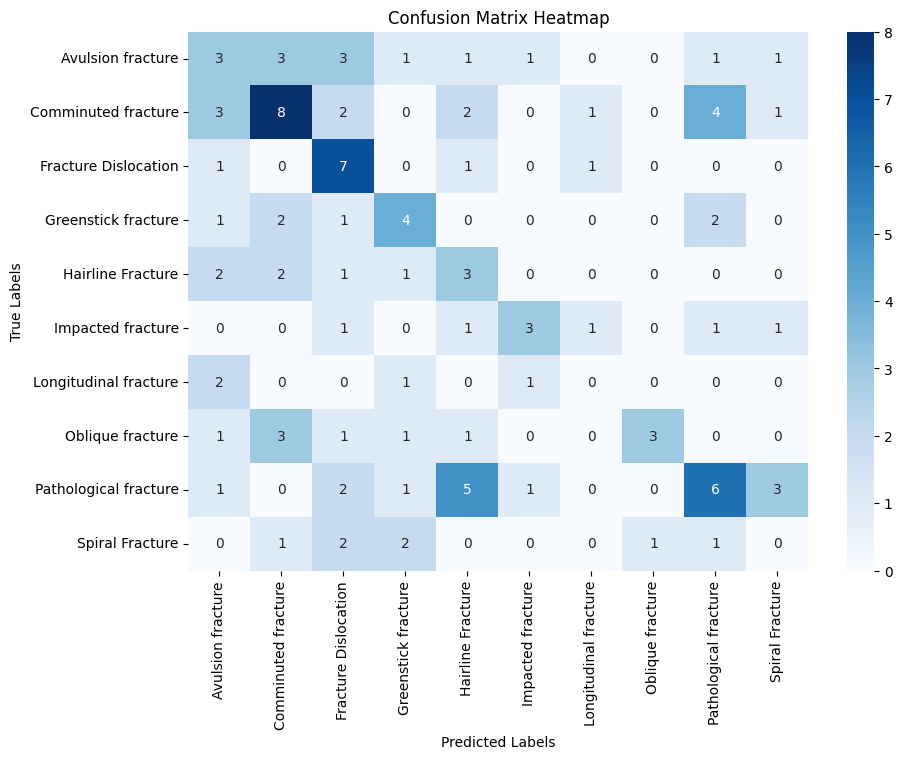

Model saved successfully.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import image_dataset_from_directory

# Load the dataset
data_dir = r"D:\acedemic\5th sem\bone fracture\Bone Break Classification\Bone Break Classification"
image_size = (256, 256)

# Load and preprocess images
train_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=image_size,
    batch_size=64,
    seed=40
)
val_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    shuffle=True,
    color_mode="rgb",
    image_size=image_size,
    batch_size=64,
    seed=40
)

# Normalize images
def normalize(image, label):
    return image / 255.0, label

train_data = train_data.map(normalize)
val_data = val_data.map(normalize)

# Convert dataset to numpy arrays
def dataset_to_numpy(dataset):
    images, labels = [], []
    for img_batch, label_batch in dataset:
        images.append(img_batch.numpy())
        labels.append(label_batch.numpy())
    return np.concatenate(images), np.concatenate(labels)

train_x, train_y = dataset_to_numpy(train_data)
val_x, val_y = dataset_to_numpy(val_data)

# Flatten images for Random Forest input
train_x_flat = train_x.reshape(train_x.shape[0], -1)
val_x_flat = val_x.reshape(val_x.shape[0], -1)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_x_flat, train_y)

# Evaluate on training set
train_preds = rf_model.predict(train_x_flat)
train_acc = accuracy_score(train_y, train_preds)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

# Evaluate on validation set
val_preds = rf_model.predict(val_x_flat)
val_acc = accuracy_score(val_y, val_preds)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

# Classification report
class_names = [
    'Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation',
    'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture',
    'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture',
    'Spiral Fracture'
]
report = classification_report(val_y, val_preds, target_names=class_names)
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(val_y, val_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Save model
import pickle
with open("random_forest_bone_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Model saved successfully.")